# Heterogeneous readout cell in an average network

The ring is held at the **population fit** — the *average HD activity* the model was validated against (R²=0.92). Only the PD readout cell is replaced by the cell being fit. Because `K_E`'s diagonal is `1/N`, that cell contributes ~0.8% of the excitation it receives, so "replace the PD cell" and "drive one cell with recorded network input" are the same model — verified exact to **5.7e-14 Hz** against the full 120-cell ring.

This avoids the artifact of the earlier per-cell fit, which built a ring of 120 identical copies of the target cell and thereby removed all heterogeneity.

**Split:** 8 network params frozen to the population (`KAPPA_E, KAPPA_I, W_EI, tau_I, tau_a` + the synaptic input gains `J1, W_IE, W_GLOBAL`); **24 cellular params fit per cell**.

**Two SC-gate variants compared:** `network` (gate from the inherited recurrent drive — the current mechanism) vs `own` (gate from the cell's own depolarization — NMDA Mg²⁺-block). Parameter-matched, so the comparison is fair.

Pipeline: `network_background.py` → `fit_cell_readout.py --all` → `compile_readout_results.py` → this notebook.

In [1]:
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import optimization_engine as oe, readout_cell as rc

net = pd.read_parquet('optimized_cells_readout_network.parquet')
own = pd.read_parquet('optimized_cells_readout_own.parquet')
npz = np.load('vivo_percell.npz', allow_pickle=True)
drv_pd   = rc.load_drivers('network_drivers.npz', 'pd')
drv_anti = rc.load_drivers('network_drivers.npz', 'anti')
CELL = rc.CELL_PARAMS
TUNING = [c for c in ['HDpeakFR','HDInx','HDAngle','HDFR','nSpk'] if c in net.columns]
print('network gate:', net.shape, ' own gate:', own.shape)
net[['Animal_Id','Cell_Id','R_Squared','FC_model','FC_data','A_sc','g_a','I_HD']].head()

network gate: (77, 48)  own gate: (77, 48)


,Animal_Id,Cell_Id,R_Squared,FC_model,FC_data,A_sc,g_a,I_HD
0,EB09,1.0,0.782277,143.381438,142.156863,89.914659,1.869785,1.627900
1,EB12,50.0,0.679721,262.671287,247.619048,74.289311,1.421941,11.870323
2,EB12,51.0,0.590222,152.855388,122.807018,194.898478,1.953199,0.641162
3,EB12,52.0,0.743404,220.238214,259.259259,107.695307,1.046908,4.288630
4,EB12,53.0,0.790365,217.599122,216.216216,84.616794,1.417909,5.561706


## Fit quality: readout vs homogeneous-ring vs phenomenological

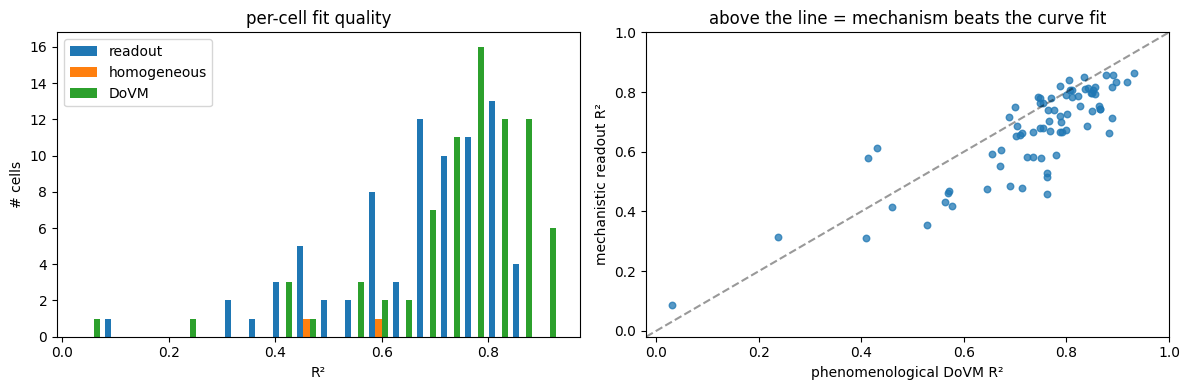

       readout  homogeneous      DoVM
mean  0.668482     0.528450  0.738513
50%   0.704215     0.528450  0.768274
min   0.087971     0.477016  0.030328
max   0.862806     0.579884  0.931861


In [2]:
key = ['Animal_Id','Cell_Id']
cmp = net[key+['R_Squared']].rename(columns={'R_Squared':'readout'})
try:
    homo = pd.read_parquet('optimized_cells_mech.parquet')[key+['R_Squared']]
    cmp = cmp.merge(homo.rename(columns={'R_Squared':'homogeneous'}), on=key, how='left')
except Exception as e:
    print('homogeneous baseline not available:', e)
phen = pd.read_csv('df.csv')[key+['R_Squared']].rename(columns={'R_Squared':'DoVM'})
cmp = cmp.merge(phen, on=key, how='left')

cols = [c for c in ['readout','homogeneous','DoVM'] if c in cmp]
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist([cmp[c].dropna().clip(-1,1) for c in cols], bins=20, label=cols)
ax[0].set_xlabel('R²'); ax[0].set_ylabel('# cells'); ax[0].legend(); ax[0].set_title('per-cell fit quality')
ax[1].scatter(cmp['DoVM'], cmp['readout'], s=22, alpha=0.75)
lim = [min(cmp[['DoVM','readout']].min())-0.05, 1.0]
ax[1].plot(lim, lim, 'k--', alpha=0.4); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel('phenomenological DoVM R²'); ax[1].set_ylabel('mechanistic readout R²')
ax[1].set_title('above the line = mechanism beats the curve fit')
plt.tight_layout(); plt.show()
print(cmp[cols].describe().loc[['mean','50%','min','max']])

## The FC is unlocked
In the homogeneous ring a tall `A_fast` destabilized the whole network, so the FC was stuck at ~half the data. With the network fixed, the readout cell's FC only drives that cell.

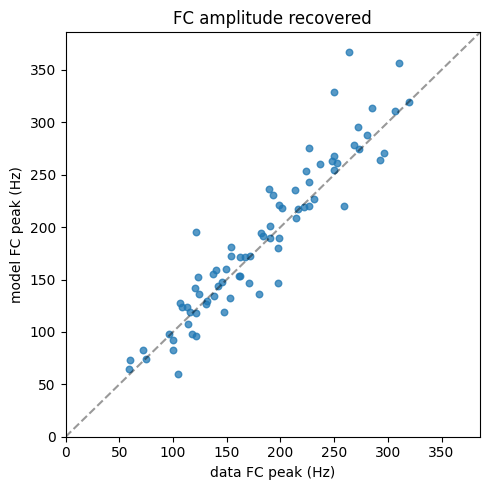

median |model-data|/data = 0.085


In [3]:
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(net['FC_data'], net['FC_model'], s=22, alpha=0.75)
lim = [0, max(net[['FC_data','FC_model']].max())*1.05]
ax.plot(lim, lim, 'k--', alpha=0.4); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('data FC peak (Hz)'); ax.set_ylabel('model FC peak (Hz)'); ax.set_title('FC amplitude recovered')
plt.tight_layout(); plt.show()
print('median |model-data|/data = %.3f' % ((net['FC_model']-net['FC_data']).abs()/net['FC_data']).median())

## SC gate: inherited network drive vs the cell's own depolarization
If the `own` (Mg-block) gate fits as well or better, per-cell SC amplitude is partly **emergent** from the cell's own depolarization rather than needing an independent per-cell drive (`A_sc`).

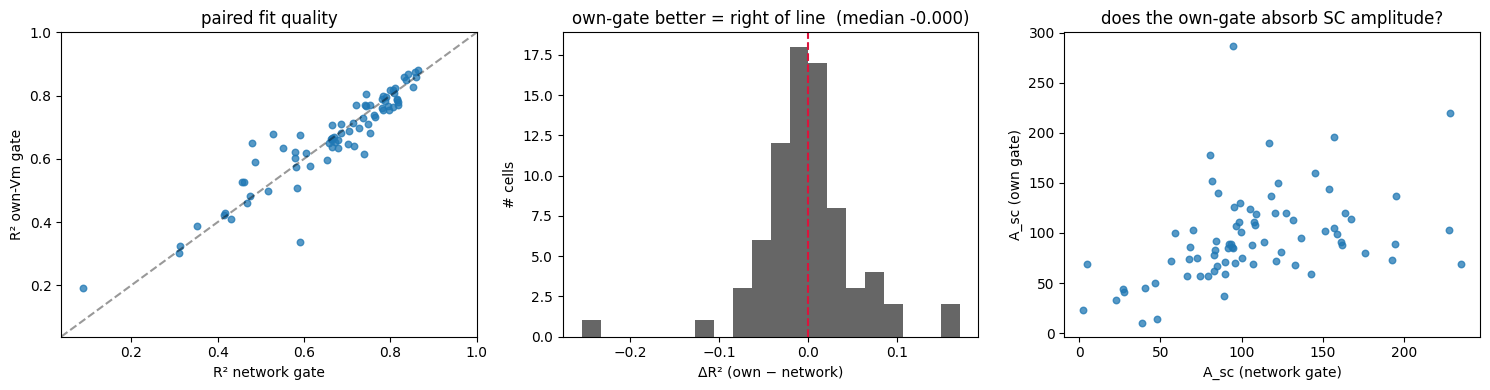

own better in 36/77 cells
A_sc spread (CV): network 0.46 | own 0.48


In [4]:
g = net[key+['R_Squared','A_sc']].merge(own[key+['R_Squared','A_sc']], on=key, suffixes=('_net','_own'))
fig, ax = plt.subplots(1, 3, figsize=(15,4))
lim = [min(g[['R_Squared_net','R_Squared_own']].min())-0.05, 1.0]
ax[0].scatter(g['R_Squared_net'], g['R_Squared_own'], s=22, alpha=0.75)
ax[0].plot(lim, lim, 'k--', alpha=0.4); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel('R² network gate'); ax[0].set_ylabel('R² own-Vm gate'); ax[0].set_title('paired fit quality')
d = g['R_Squared_own'] - g['R_Squared_net']
ax[1].hist(d, bins=20, color='0.4'); ax[1].axvline(0, color='crimson', ls='--')
ax[1].set_xlabel('ΔR² (own − network)'); ax[1].set_ylabel('# cells')
ax[1].set_title('own-gate better = right of line  (median %.3f)' % d.median())
ax[2].scatter(g['A_sc_net'], g['A_sc_own'], s=22, alpha=0.75)
ax[2].set_xlabel('A_sc (network gate)'); ax[2].set_ylabel('A_sc (own gate)')
ax[2].set_title('does the own-gate absorb SC amplitude?')
plt.tight_layout(); plt.show()
print('own better in %d/%d cells' % ((d>0).sum(), len(d)))
print('A_sc spread (CV): network %.2f | own %.2f' % (g['A_sc_net'].std()/g['A_sc_net'].mean(), g['A_sc_own'].std()/g['A_sc_own'].mean()))

## Cellular parameter distributions across the 77 cells

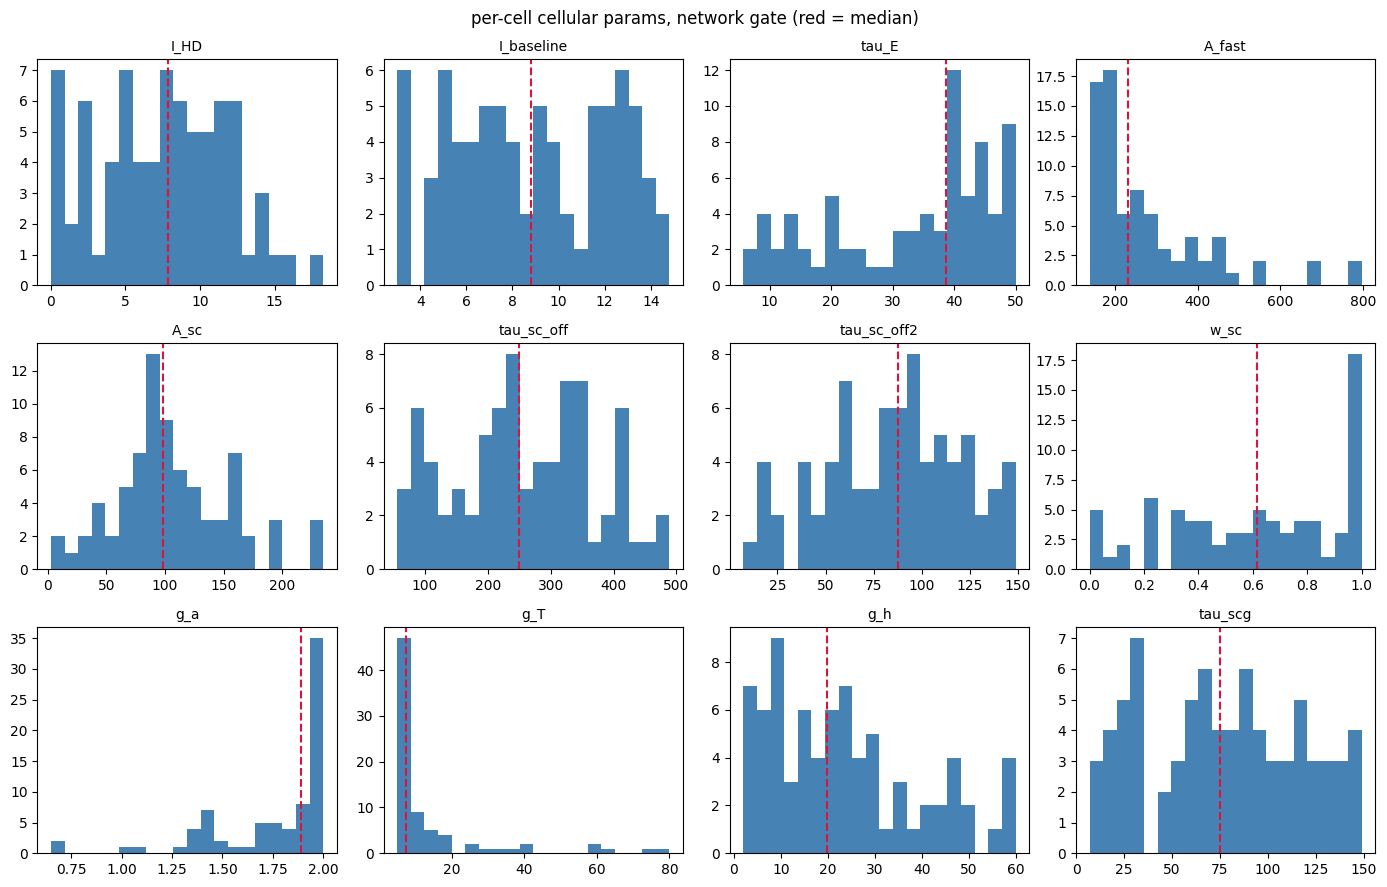

In [5]:
SPOT = ['I_HD','I_baseline','tau_E','A_fast','A_sc','tau_sc_off','tau_sc_off2','w_sc','g_a','g_T','g_h','tau_scg']
fig, axes = plt.subplots(3, 4, figsize=(14,9))
for ax, p in zip(axes.ravel(), SPOT):
    ax.hist(net[p], bins=20, color='steelblue')
    ax.axvline(net[p].median(), color='crimson', ls='--')
    ax.set_title(p, fontsize=10)
fig.suptitle('per-cell cellular params, network gate (red = median)')
plt.tight_layout(); plt.show()

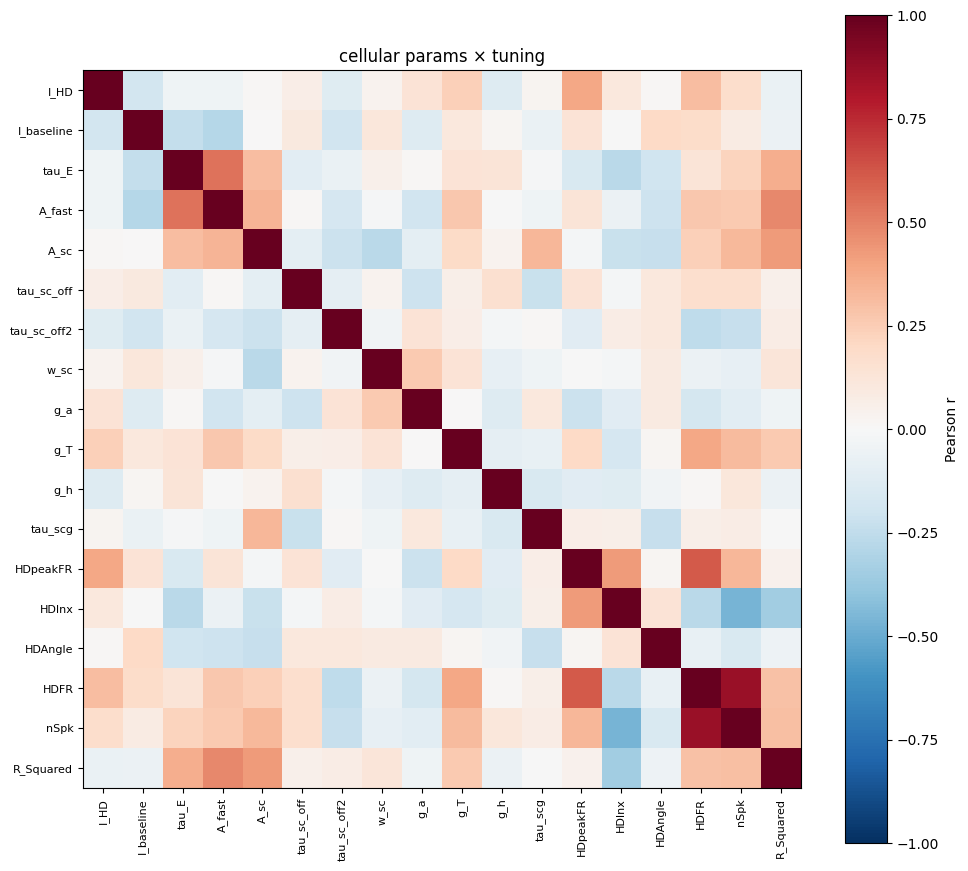

In [6]:
cols = SPOT + TUNING + ['R_Squared']
corr = net[cols].corr()
fig, ax = plt.subplots(figsize=(10,9))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
fig.colorbar(im, label='Pearson r'); ax.set_title('cellular params × tuning')
plt.tight_layout(); plt.show()

## Per-component decomposition
Single-component knockouts on the readout cell: −SC, −adaptation, −channels, −FC.

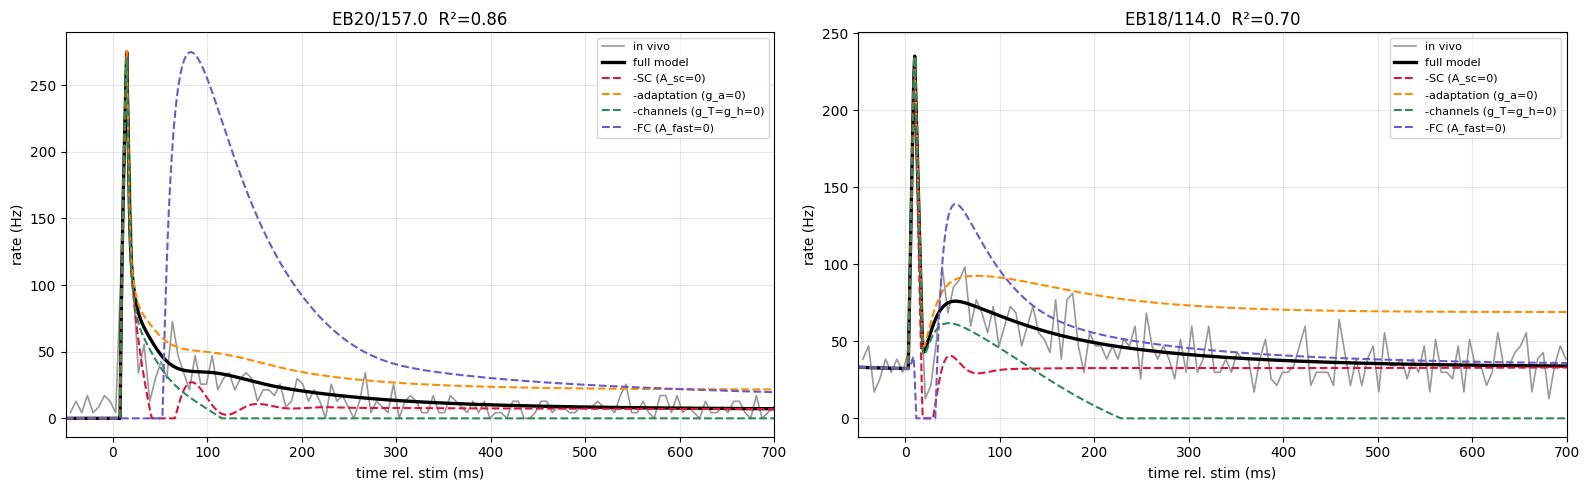

In [7]:
def show_decomp(row, df_src, gate_own, drv=drv_pd, ax=None):
    an, cid = row['Animal_Id'], float(row['Cell_Id'])
    ids = list(zip([str(a) for a in npz['animal_ids']], [float(c) for c in npz['cell_ids']]))
    i = ids.index((str(an), cid))
    b, pr = npz['bins'], npz['pd_rate'][i]
    p = [float(row[k]) for k in CELL]
    ks = rc.knockouts(p, drv, gate_own); t = drv[0]
    if ax is None: _, ax = plt.subplots(figsize=(9,5))
    m = (b>=-50)&(b<=700)
    ax.plot(b[m], pr[m], color='0.6', lw=1.2, label='in vivo')
    ax.plot(t, ks['full'], color='black', lw=2.4, label='full model')
    for lab, c in zip([k for k in ks if k!='full'], ['crimson','darkorange','seagreen','slateblue']):
        ax.plot(t, ks[lab], color=c, lw=1.5, ls='--', label=lab)
    ax.set_xlim(-50,700); ax.set_xlabel('time rel. stim (ms)'); ax.set_ylabel('rate (Hz)')
    ax.set_title(f"{an}/{cid}  R²={row['R_Squared']:.2f}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    return ax

best = net.loc[net['R_Squared'].idxmax()]
med  = net.iloc[(net['R_Squared'] - net['R_Squared'].median()).abs().argsort().iloc[0]]
fig, axes = plt.subplots(1, 2, figsize=(16,5))
show_decomp(best, net, 0, ax=axes[0]); show_decomp(med, net, 0, ax=axes[1])
plt.tight_layout(); plt.show()

## Held-out test: predict each cell's ANTI-PD response
Take each cell's params — fit **only** on its PD trace — and drive them with the antipode's network input. The measured anti-PD PSTH was never used in fitting. This is a direct test of the emergent-tuning claim: the SC should collapse at the antipode.

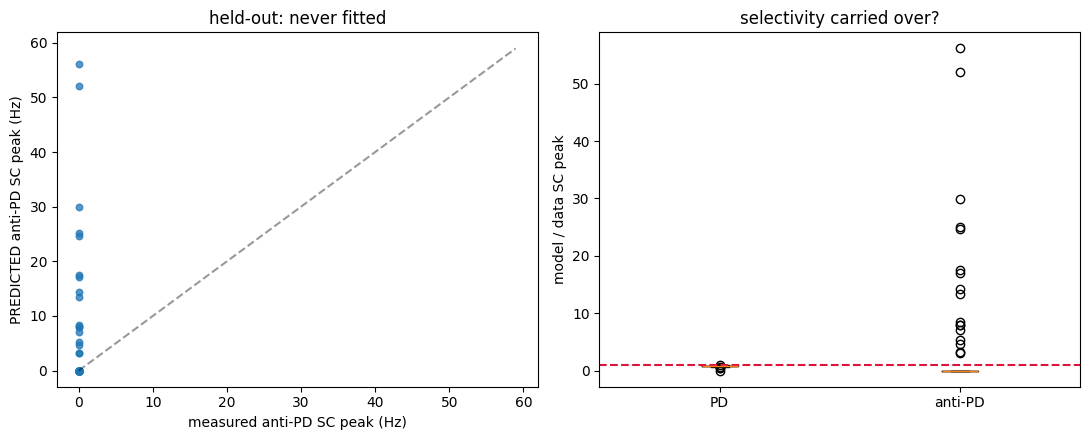

median SC peak — model PD 82.7, model anti 0.0 | data PD 101.9, data anti 0.0 Hz


In [8]:
ids = list(zip([str(a) for a in npz['animal_ids']], [float(c) for c in npz['cell_ids']]))
t = drv_pd[0]; b = npz['bins']; sc = (t>40)&(t<300); scb = (b>40)&(b<300)
rows = []
for _, r in net.iterrows():
    i = ids.index((str(r['Animal_Id']), float(r['Cell_Id'])))
    p = np.array([float(r[k]) for k in CELL])
    y_pd   = rc.simulate_readout(p, *drv_pd, 0)
    y_anti = rc.simulate_readout(p, *drv_anti, 0)
    rows.append(dict(pd_model=y_pd[sc].max(), anti_model=y_anti[sc].max(),
                     pd_data=npz['pd_rate'][i][scb].max(), anti_data=npz['anti_rate'][i][scb].max()))
h = pd.DataFrame(rows)
fig, ax = plt.subplots(1,2, figsize=(11,4.5))
ax[0].scatter(h['anti_data'], h['anti_model'], s=22, alpha=0.75)
lim=[0, max(h[['anti_data','anti_model']].max())*1.05]; ax[0].plot(lim,lim,'k--',alpha=.4)
ax[0].set_xlabel('measured anti-PD SC peak (Hz)'); ax[0].set_ylabel('PREDICTED anti-PD SC peak (Hz)')
ax[0].set_title('held-out: never fitted')
ax[1].boxplot([h['pd_model']/h['pd_data'].clip(lower=1), h['anti_model']/h['anti_data'].clip(lower=1)], tick_labels=['PD','anti-PD'])
ax[1].axhline(1, color='crimson', ls='--'); ax[1].set_ylabel('model / data SC peak')
ax[1].set_title('selectivity carried over?')
plt.tight_layout(); plt.show()
print('median SC peak — model PD %.1f, model anti %.1f | data PD %.1f, data anti %.1f Hz'
      % (h['pd_model'].median(), h['anti_model'].median(), h['pd_data'].median(), h['anti_data'].median()))

## Self-consistency
The approach assumes cell heterogeneity is ~zero-mean around the average network. If so, the **mean of the 77 fitted readout traces** should approximate the population PSTH the network itself was fit to. If it doesn't, that assumption is violated and must be reported.

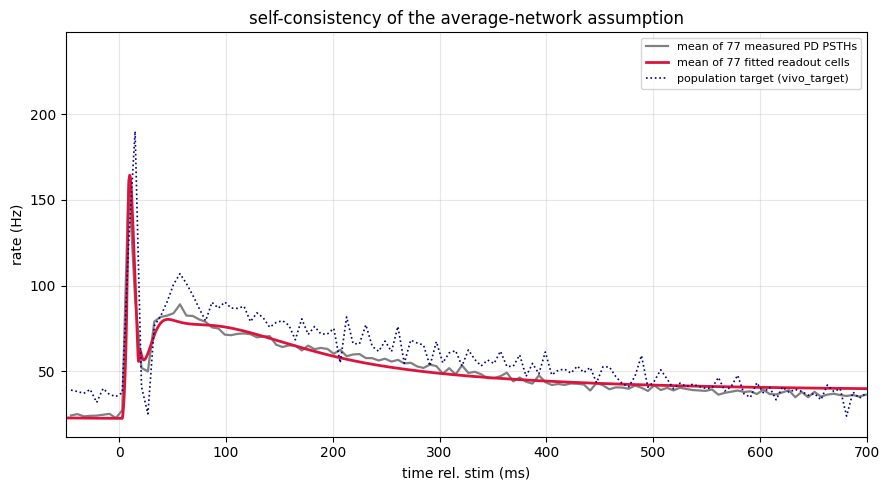

R² (mean fitted vs mean measured) = 0.966


In [9]:
from vivo_target import load_vivo_psth
vb, vr, vs = load_vivo_psth()
Y = np.vstack([rc.simulate_readout(np.array([float(r[k]) for k in CELL]), *drv_pd, 0)
               for _, r in net.iterrows()])
mean_model = Y.mean(axis=0)
mean_data  = npz['pd_rate'].mean(axis=0)
fig, ax = plt.subplots(figsize=(9,5))
m = (b>=-50)&(b<=700)
ax.plot(b[m], mean_data[m], color='0.5', lw=1.6, label='mean of 77 measured PD PSTHs')
ax.plot(t, mean_model, color='crimson', lw=2, label='mean of 77 fitted readout cells')
ax.plot(vb[(vb>=-50)&(vb<=700)], vr[(vb>=-50)&(vb<=700)], color='navy', lw=1.2, ls=':', label='population target (vivo_target)')
ax.set_xlim(-50,700); ax.set_xlabel('time rel. stim (ms)'); ax.set_ylabel('rate (Hz)')
ax.set_title('self-consistency of the average-network assumption'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
mm = np.interp(b[m], t, mean_model)
print('R² (mean fitted vs mean measured) = %.3f' % (1 - np.sum((mean_data[m]-mm)**2)/np.sum((mean_data[m]-mean_data[m].mean())**2)))